In [153]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as f
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [154]:
df = pd.read_csv('/content/drive/MyDrive/Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [155]:
class Model(nn.Module):

  def __init__(self, in_features=4 ,h1=8,h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features , h1)
    self.fc2 = nn.Linear(h1 , h2)
    self.out = nn.Linear(h2 , out_features)

  def forward(self , x):
    x = f.relu(self.fc1(x))
    x = f.relu(self.fc2(x))
    x = self.out(x)

    return x

In [156]:
torch.manual_seed(32)

model = Model()

In [157]:
import matplotlib.pyplot as plt
%matplotlib inline

In [158]:
df['Species'] = df['Species'].map({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

In [159]:
x = df.drop(['Species', 'Id'], axis=1)
y = df['Species']

In [160]:
x = x.values
y = y.values

In [161]:
from sklearn.model_selection import train_test_split

In [162]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 , random_state=32)

In [163]:
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

In [164]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [165]:
from torch.optim import optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [166]:
epoch = 100
losses = []
for i in range(epoch):

  y_pred = model.forward(x_train)

  loss = criterion(y_pred , y_train)

  losses.append(loss.detach().numpy())

  if i % 10 == 0:
    print(f'Epoch : {i} and loss : {loss} ')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()




Epoch : 0 and loss : 1.169895887374878 
Epoch : 10 and loss : 0.9578844308853149 
Epoch : 20 and loss : 0.7988812923431396 
Epoch : 30 and loss : 0.634953498840332 
Epoch : 40 and loss : 0.44043001532554626 
Epoch : 50 and loss : 0.291716992855072 
Epoch : 60 and loss : 0.17829042673110962 
Epoch : 70 and loss : 0.11587586998939514 
Epoch : 80 and loss : 0.08928147703409195 
Epoch : 90 and loss : 0.07743765413761139 


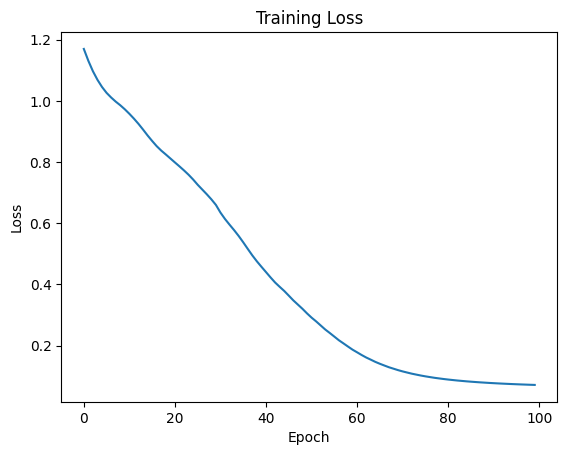

In [167]:
plt.plot(range(epoch), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.title("Training Loss")
plt.savefig("training_loss.png")
plt.show()

In [168]:
with torch.no_grad():
  y_eval = model(x_test)
  loss = criterion(y_eval , y_test)

In [169]:
loss

tensor(0.0539)

In [170]:
correct = 0
with torch.no_grad():
  for i , data in enumerate(x_test):
    y_val = model.forward(data)

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    #correct or not
    if y_val.argmax().item() == y_test[i]:
       correct += 1
  print(f"we got {correct} correct!")

1.) tensor([-3.3580,  3.9452,  0.3616]) 	 1 	 1
2.) tensor([  7.5862,   1.1113, -11.3861]) 	 0 	 0
3.) tensor([  6.6288,   1.5092, -10.4603]) 	 0 	 0
4.) tensor([-3.3304,  4.2647,  0.0569]) 	 1 	 1
5.) tensor([-7.3705,  2.8135,  5.1481]) 	 2 	 2
6.) tensor([-7.3749,  3.9061,  4.2781]) 	 2 	 2
7.) tensor([  6.2304,   1.6527, -10.0543]) 	 0 	 0
8.) tensor([  6.8783,   1.4056, -10.7016]) 	 0 	 0
9.) tensor([-2.6728,  4.3138, -0.6444]) 	 1 	 1
10.) tensor([  7.2201,   1.3890, -11.1494]) 	 0 	 0
11.) tensor([-3.8269,  4.4110,  0.5165]) 	 1 	 1
12.) tensor([-8.6886,  1.9990,  6.9012]) 	 2 	 2
13.) tensor([-2.0605,  3.8275, -0.7672]) 	 1 	 1
14.) tensor([-1.0676,  4.3809, -2.2975]) 	 1 	 1
15.) tensor([-7.5000,  2.6230,  5.3318]) 	 2 	 2
16.) tensor([-8.6214,  1.5491,  7.1280]) 	 2 	 2
17.) tensor([-3.7724,  3.6503,  0.9422]) 	 1 	 1
18.) tensor([-6.7624,  2.7791,  4.5289]) 	 2 	 2
19.) tensor([-1.6978,  4.2047, -1.4772]) 	 1 	 1
20.) tensor([  7.8104,   1.3824, -11.9435]) 	 0 	 0
21.) tensor

In [171]:
new_iris = torch.tensor([5.9	,3.0,	5.1	,1.8])

In [172]:
with torch.no_grad():
  print(model(new_iris))

tensor([-6.7319,  2.6637,  4.5465])


In [173]:
torch.save(model.state_dict(), 'iris_model.pt')

In [174]:
new_model = Model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [175]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)